# Exploratory Data Analysis & Data Preprocessing Pipeline

This project demonstrates a complete data preprocessing and exploratory analysis workflow using Python for preparing structured datasets for machine learning and analytical tasks.


## 1.  Setup & Data Loading <a name='setup'></a>

In [109]:
# Install required libraries
!pip install ydata-profiling -q

In [110]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import boxcox

# Sklearn imports
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, OrdinalEncoder,
    MinMaxScaler, StandardScaler, RobustScaler,
    QuantileTransformer, PolynomialFeatures, FunctionTransformer
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print(' All libraries imported successfully!')

 All libraries imported successfully!


In [111]:
# Load the Titanic dataset from seaborn (built-in, no download needed)
df = sns.load_dataset('titanic')
print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')

Dataset loaded successfully!
Shape: (891, 15)


---
## 2.  Data Understanding <a name='understanding'></a>

Data understanding involves asking key questions about the dataset structure, content, and quality.

In [112]:
#  How big is the data?
print('Shape of dataset (rows, columns):')
print(df.shape)

Shape of dataset (rows, columns):
(891, 15)


In [113]:
#  What are the features and first few records?
print('First 5 rows:')
df.head()

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.00,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.00,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.00,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.00,1,0,53.10,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.00,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True


In [114]:
# Last 5 rows
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.00,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.00,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.00,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.00,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [115]:
#  What are the data types of each feature?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [116]:
#  Are there any missing values?
missing = df.isnull().sum()
print('Missing values:')
print(missing)

Missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


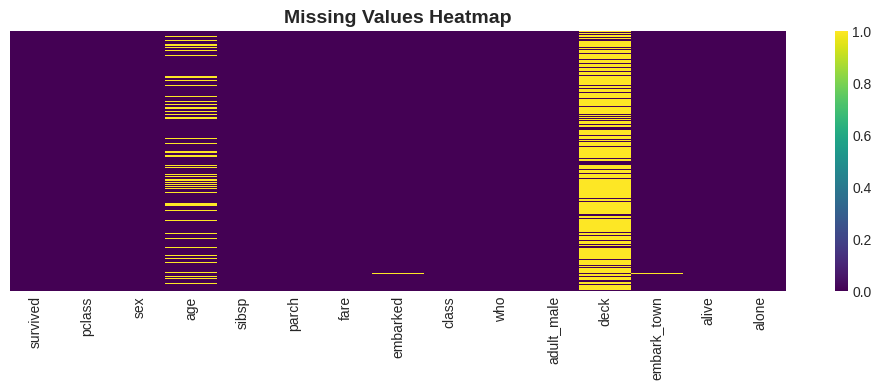

In [117]:
# Visualize missing values
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [118]:
#  How does the data look mathematically?
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


In [119]:
#  Are there any duplicate rows?
print(f'Number of duplicate rows: {df.duplicated().sum()}')

Number of duplicate rows: 107


---
## 3.  Univariate Analysis <a name='univariate'></a>

Univariate analysis explores each variable **individually** to understand its distribution and characteristics.

### 3a. Categorical Variables

/tmp/ipython-input-1134283075.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='survived', data=df, ax=axes[0], palette='Set2')
/tmp/ipython-input-1134283075.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, ax=axes[1], palette='Set2')
/tmp/ipython-input-1134283075.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pclass', data=df, ax=axes[2], palette='Set2')


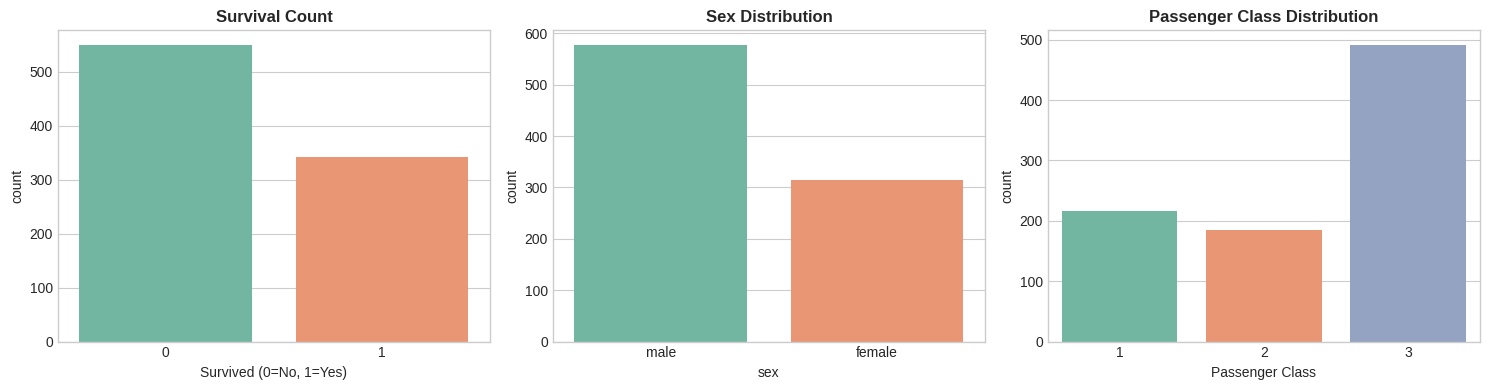

In [120]:
# Bar chart for categorical variable: Survived
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x='survived', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Survival Count', fontweight='bold')
axes[0].set_xlabel('Survived (0=No, 1=Yes)')

sns.countplot(x='sex', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Sex Distribution', fontweight='bold')

sns.countplot(x='pclass', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Passenger Class Distribution', fontweight='bold')
axes[2].set_xlabel('Passenger Class')

plt.tight_layout()
plt.show()

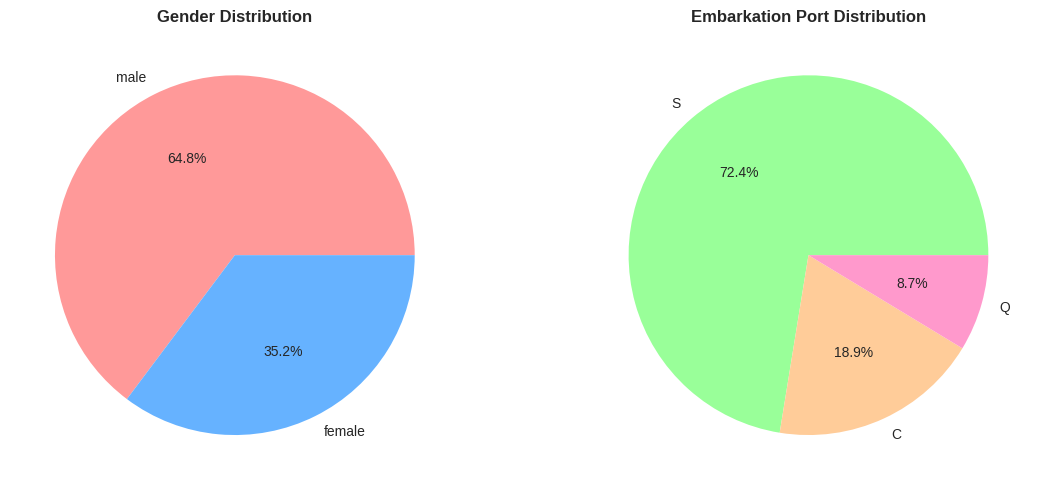

In [121]:
# Pie chart: Percentage distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['sex'].value_counts().plot(kind='pie', autopct='%0.1f%%', ax=axes[0], colors=['#FF9999','#66B2FF'])
axes[0].set_title('Gender Distribution', fontweight='bold')
axes[0].set_ylabel('')

df['embarked'].value_counts().plot(kind='pie', autopct='%0.1f%%', ax=axes[1], colors=['#99FF99','#FFCC99','#FF99CC'])
axes[1].set_title('Embarkation Port Distribution', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 3b. Numerical Variables

In [122]:
# Statistical measures for numerical variables
num_cols = ['age', 'fare', 'sibsp', 'parch']
print('Statistical Summary:')
for col in num_cols:
    print(f'\n{col.upper()}')
    print(f'  Mean   : {df[col].mean():.2f}')
    print(f'  Median : {df[col].median():.2f}')
    print(f'  Std Dev: {df[col].std():.2f}')
    print(f'  Skewness: {df[col].skew():.2f}')

Statistical Summary:

AGE
  Mean   : 29.70
  Median : 28.00
  Std Dev: 14.53
  Skewness: 0.39

FARE
  Mean   : 32.20
  Median : 14.45
  Std Dev: 49.69
  Skewness: 4.79

SIBSP
  Mean   : 0.52
  Median : 0.00
  Std Dev: 1.10
  Skewness: 3.70

PARCH
  Mean   : 0.38
  Median : 0.00
  Std Dev: 0.81
  Skewness: 2.75


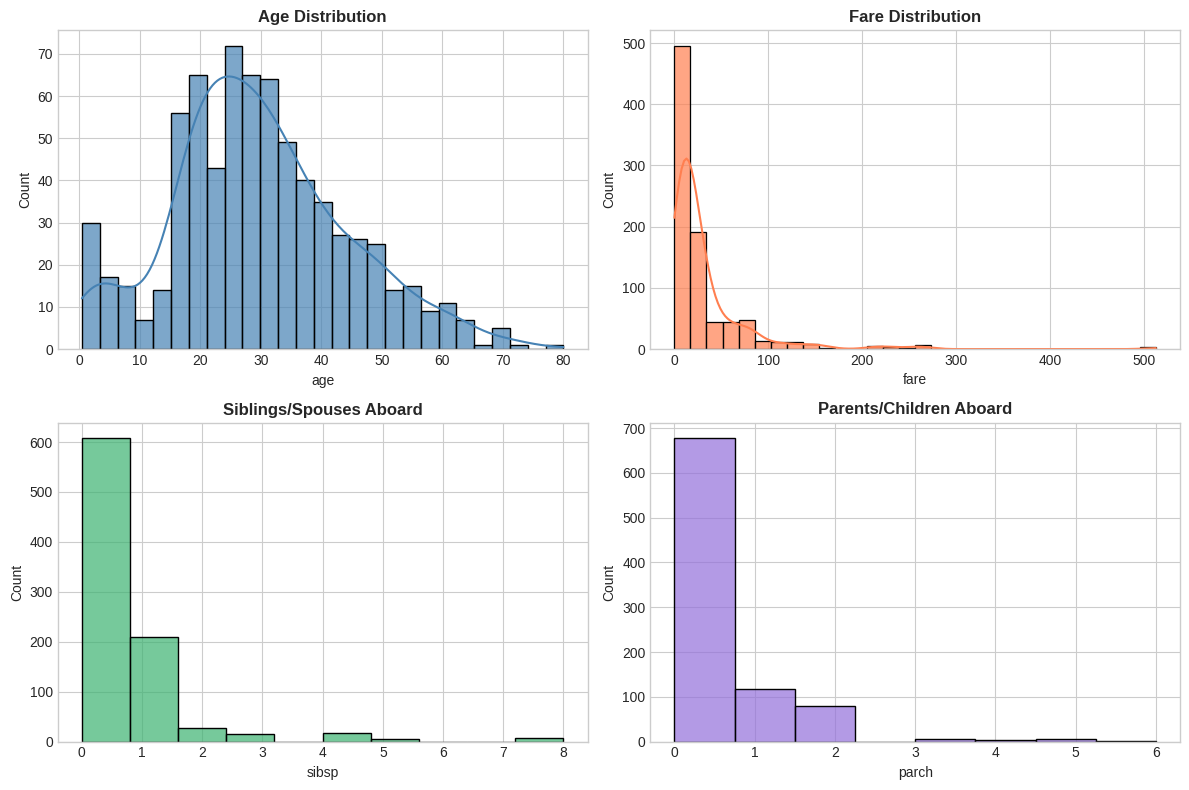

In [123]:
# Histograms for numerical variables
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['age'].dropna(), bins=27, color='steelblue', alpha=0.7, ax=axes[0][0], kde=True)
axes[0][0].set_title('Age Distribution', fontweight='bold')

sns.histplot(df['fare'], bins=30, color='coral', alpha=0.7, ax=axes[0][1], kde=True)
axes[0][1].set_title('Fare Distribution', fontweight='bold')

sns.histplot(df['sibsp'], bins=10, color='mediumseagreen', alpha=0.7, ax=axes[1][0], kde=False)
axes[1][0].set_title('Siblings/Spouses Aboard', fontweight='bold')

sns.histplot(df['parch'], bins=8, color='mediumpurple', alpha=0.7, ax=axes[1][1], kde=False)
axes[1][1].set_title('Parents/Children Aboard', fontweight='bold')

plt.tight_layout()
plt.show()

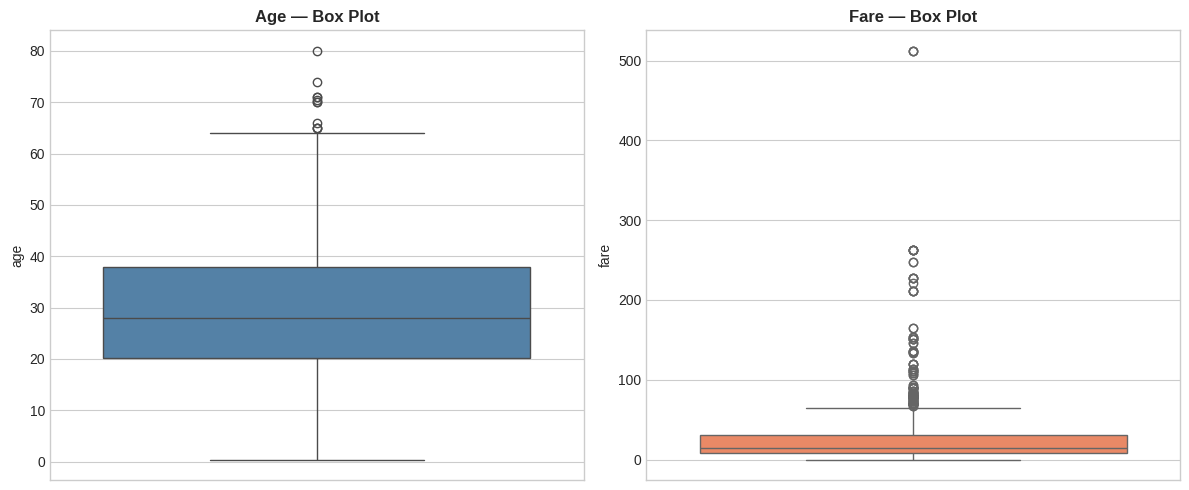

Dots beyond the whiskers = Outliers!


In [124]:
# Box plots for numerical variables (outlier detection)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['age'], ax=axes[0], color='steelblue')
axes[0].set_title('Age — Box Plot', fontweight='bold')

sns.boxplot(y=df['fare'], ax=axes[1], color='coral')
axes[1].set_title('Fare — Box Plot', fontweight='bold')

plt.tight_layout()
plt.show()

print('Dots beyond the whiskers = Outliers!')

---
## 4.  Bivariate Analysis <a name='bivariate'></a>

Bivariate analysis explores the **relationship between two variables**.

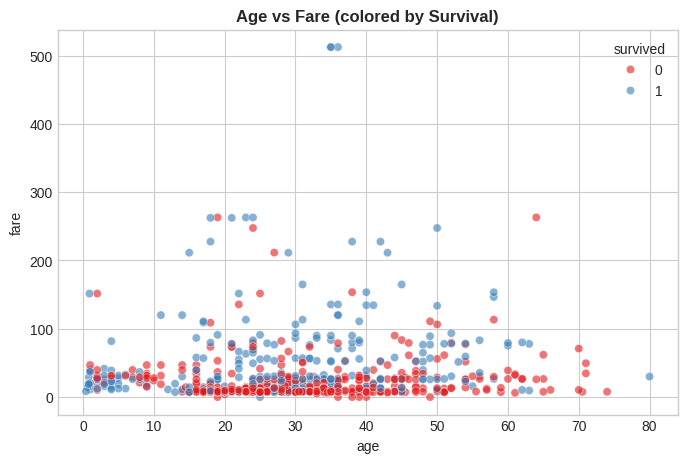

In [125]:
# Numerical vs Numerical: Scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='fare', hue='survived', data=df, palette='Set1', alpha=0.6)
plt.title('Age vs Fare (colored by Survival)', fontweight='bold')
plt.show()

/tmp/ipython-input-2421931288.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pclass', y='age', data=df, ax=axes[0], palette='pastel')
/tmp/ipython-input-2421931288.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='survived', y='fare', data=df, ax=axes[1], palette='Set2')


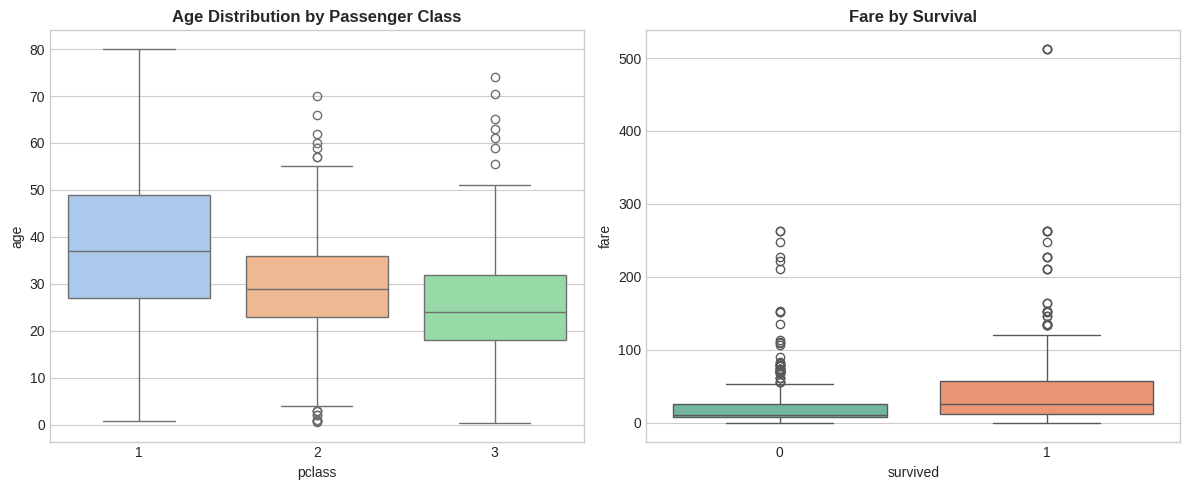

In [126]:
# Categorical vs Numerical: Box plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='pclass', y='age', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Age Distribution by Passenger Class', fontweight='bold')

sns.boxplot(x='survived', y='fare', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Fare by Survival', fontweight='bold')

plt.tight_layout()
plt.show()

Crosstab: Sex vs Survived
survived    0    1
sex               
female     81  233
male      468  109


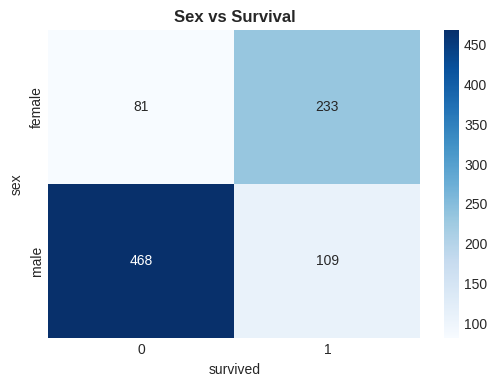

In [127]:
# Categorical vs Categorical: Crosstab / Heatmap
ct = pd.crosstab(df['sex'], df['survived'])
print('Crosstab: Sex vs Survived')
print(ct)

plt.figure(figsize=(6, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Sex vs Survival', fontweight='bold')
plt.show()

---
## 5.  Multivariate Analysis <a name='multivariate'></a>

Multivariate analysis explores **relationships among multiple variables simultaneously**.

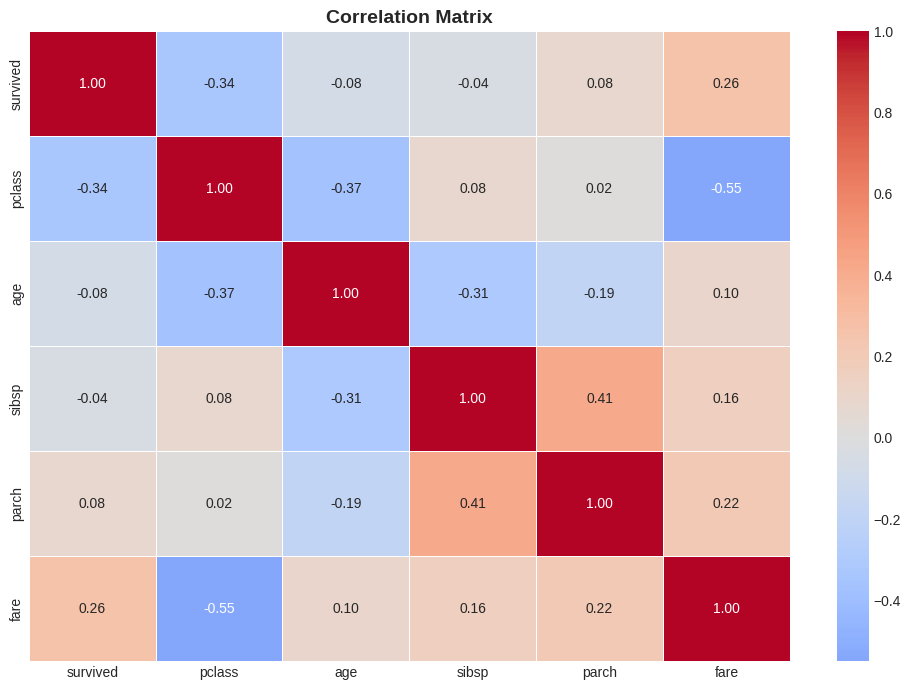

In [128]:
# Correlation matrix heatmap
plt.figure(figsize=(10, 7))
corr = df[['survived','pclass','age','sibsp','parch','fare']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

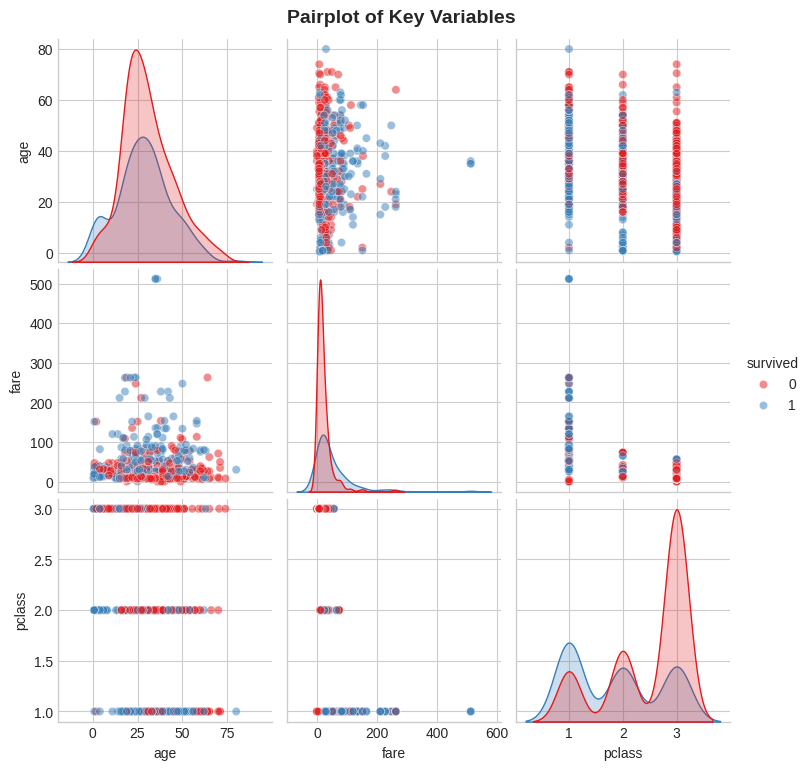

In [129]:
# Pairplot: multiple variable relationships at once
sns.pairplot(df[['survived','age','fare','pclass']].dropna(),
             hue='survived', palette='Set1', plot_kws={'alpha':0.5})
plt.suptitle('Pairplot of Key Variables', y=1.02, fontsize=14, fontweight='bold')
plt.show()

<Figure size 1000x500 with 0 Axes>

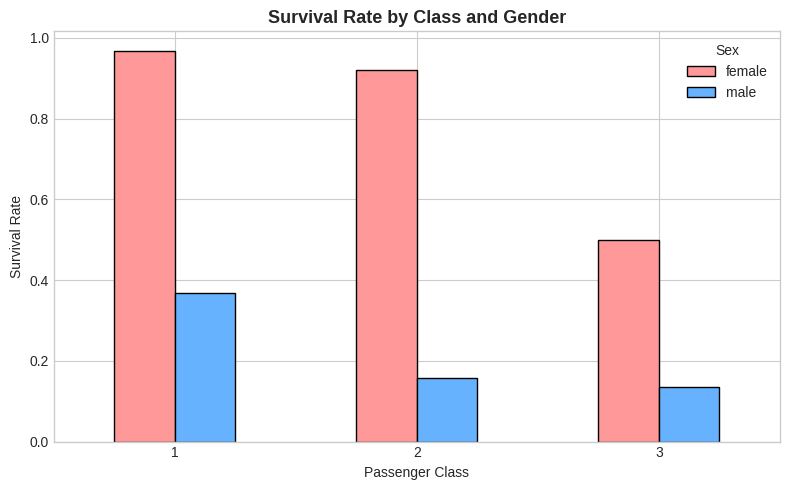

In [130]:
# Multi-facet analysis: Survival by Sex and Passenger Class
plt.figure(figsize=(10, 5))
survival_rate = df.groupby(['pclass','sex'])['survived'].mean().unstack()
survival_rate.plot(kind='bar', figsize=(8, 5), color=['#FF9999', '#66B2FF'], edgecolor='black')
plt.title('Survival Rate by Class and Gender', fontweight='bold', fontsize=13)
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

---
## 6. Automated EDA with ydata-profiling <a name='profiling'></a>

ydata-profiling (formerly pandas-profiling) automatically generates a comprehensive EDA report.

In [131]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title='Titanic EDA Report', explorative=True)

# Display in notebook
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:00<00:00, 66.64it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

---
## 7.  Data Cleaning <a name='cleaning'></a>

Data cleaning fixes or removes incorrect, corrupted, duplicate, or incomplete data.

In [132]:
# Work on a copy to preserve original data
df_clean = df.copy()
print('Original shape:', df_clean.shape)

Original shape: (891, 15)


In [133]:
#  Drop unnecessary columns
cols_to_drop = ['deck', 'embark_town', 'alive', 'who', 'adult_male', 'alone', 'class']
df_clean.drop(columns=cols_to_drop, inplace=True)
print('After dropping unnecessary columns:', df_clean.shape)
print('Remaining columns:', df_clean.columns.tolist())

After dropping unnecessary columns: (891, 8)
Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


In [134]:
#  Check missing values again
print('Missing values:')
print(df_clean.isnull().sum())

Missing values:
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64


In [135]:
#  Handle Missing Values

# Mean Imputation for 'age' (numerical)
df_clean['age'].fillna(df_clean['age'].mean(), inplace=True)

# Mode Imputation for 'embarked' (categorical)
df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace=True)

print('Missing values after imputation:')
print(df_clean.isnull().sum())

Missing values after imputation:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


/tmp/ipython-input-2286141399.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['age'].fillna(df_clean['age'].mean(), inplace=True)
/tmp/ipython-input-2286141399.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [136]:
#  Duplicate rows
print(f'Duplicate rows before: {df_clean.duplicated().sum()}')
df_clean.drop_duplicates(inplace=True)
print(f'Duplicate rows after: {df_clean.duplicated().sum()}')
print('Shape after removing duplicates:', df_clean.shape)

Duplicate rows before: 111
Duplicate rows after: 0
Shape after removing duplicates: (780, 8)


In [137]:
#  Handle Outliers using IQR Method (for 'fare')
print('Fare statistics before outlier removal:')
print(df_clean['fare'].describe())

Q1 = df_clean['fare'].quantile(0.25)
Q3 = df_clean['fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f'\nLower bound: {lower:.2f}')
print(f'Upper bound: {upper:.2f}')

outliers_count = df_clean[(df_clean['fare'] < lower) | (df_clean['fare'] > upper)].shape[0]
print(f'Number of outliers: {outliers_count}')

# Remove outliers
df_no_outliers = df_clean[(df_clean['fare'] >= lower) & (df_clean['fare'] <= upper)]
print(f'Shape after removing fare outliers: {df_no_outliers.shape}')

Fare statistics before outlier removal:
count   780.00
mean     34.83
std      52.26
min       0.00
25%       8.05
50%      15.95
75%      34.38
max     512.33
Name: fare, dtype: float64

Lower bound: -31.44
Upper bound: 73.86
Number of outliers: 97
Shape after removing fare outliers: (683, 8)


In [138]:
# Handle Outliers using Z-Score Method
from scipy import stats

z_scores = np.abs(stats.zscore(df_clean['fare']))
threshold = 3
df_zscore_clean = df_clean[z_scores <= threshold]
print(f'Z-Score method — Shape after removing outliers: {df_zscore_clean.shape}')

Z-Score method — Shape after removing outliers: (760, 8)


---
## 8.  Feature Encoding <a name='encoding'></a>

Feature encoding converts categorical data into numerical format for ML algorithms.

In [139]:
df_enc = df_clean.copy()
print('Categorical columns:', df_enc.select_dtypes(include='object').columns.tolist())

Categorical columns: ['sex', 'embarked']


In [140]:
#  1. Label Encoding — for 'sex' (binary category)
le = LabelEncoder()
df_enc['sex_encoded'] = le.fit_transform(df_enc['sex'])
print('Label Encoding (sex):')
print(df_enc[['sex', 'sex_encoded']].drop_duplicates().sort_values('sex'))

Label Encoding (sex):
      sex  sex_encoded
1  female            0
0    male            1


In [141]:
#  2. One-Hot Encoding — for 'embarked' (no ordinal relationship)
ohe_df = pd.get_dummies(df_enc, columns=['embarked'], prefix='embarked')
print('One-Hot Encoding (embarked):')
print(ohe_df[['embarked_C', 'embarked_Q', 'embarked_S']].head())

One-Hot Encoding (embarked):
   embarked_C  embarked_Q  embarked_S
0       False       False        True
1        True       False       False
2       False       False        True
3       False       False        True
4       False       False        True


In [142]:
#  3. Ordinal Encoding — for ordered categories
# Create a sample column with ordered categories for demonstration
df_enc['ticket_type'] = pd.cut(df_enc['fare'], bins=3, labels=['Low', 'Medium', 'High'])

oe = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
df_enc['ticket_encoded'] = oe.fit_transform(df_enc[['ticket_type']])

print('Ordinal Encoding (ticket_type):')
print(df_enc[['ticket_type', 'ticket_encoded']].drop_duplicates().sort_values('ticket_encoded'))

Ordinal Encoding (ticket_type):
    ticket_type  ticket_encoded
0           Low            0.00
27       Medium            1.00
258        High            2.00


---
## 9. Feature Scaling & Transformation <a name='scaling'></a>

In [143]:
# Prepare numerical data
num_data = df_clean[['age', 'fare']].copy()

#  1. Min-Max Scaling (Normalization) — scales to [0, 1]
mm_scaler = MinMaxScaler()
mm_scaled = mm_scaler.fit_transform(num_data)
mm_df = pd.DataFrame(mm_scaled, columns=['age_minmax', 'fare_minmax'])

#  2. Standard Scaling (Standardization) — mean=0, std=1
std_scaler = StandardScaler()
std_scaled = std_scaler.fit_transform(num_data)
std_df = pd.DataFrame(std_scaled, columns=['age_std', 'fare_std'])

#  3. Robust Scaling — uses IQR, robust to outliers
rob_scaler = RobustScaler()
rob_scaled = rob_scaler.fit_transform(num_data)
rob_df = pd.DataFrame(rob_scaled, columns=['age_robust', 'fare_robust'])

print('Original Stats:')
print(num_data.describe().round(2))
print('\nMin-Max Scaled Stats:')
print(mm_df.describe().round(2))

Original Stats:
         age   fare
count 780.00 780.00
mean   29.80  34.83
std    13.71  52.26
min     0.42   0.00
25%    21.75   8.05
50%    29.70  15.95
75%    36.00  34.38
max    80.00 512.33

Min-Max Scaled Stats:
       age_minmax  fare_minmax
count      780.00       780.00
mean         0.37         0.07
std          0.17         0.10
min          0.00         0.00
25%          0.27         0.02
50%          0.37         0.03
75%          0.45         0.07
max          1.00         1.00


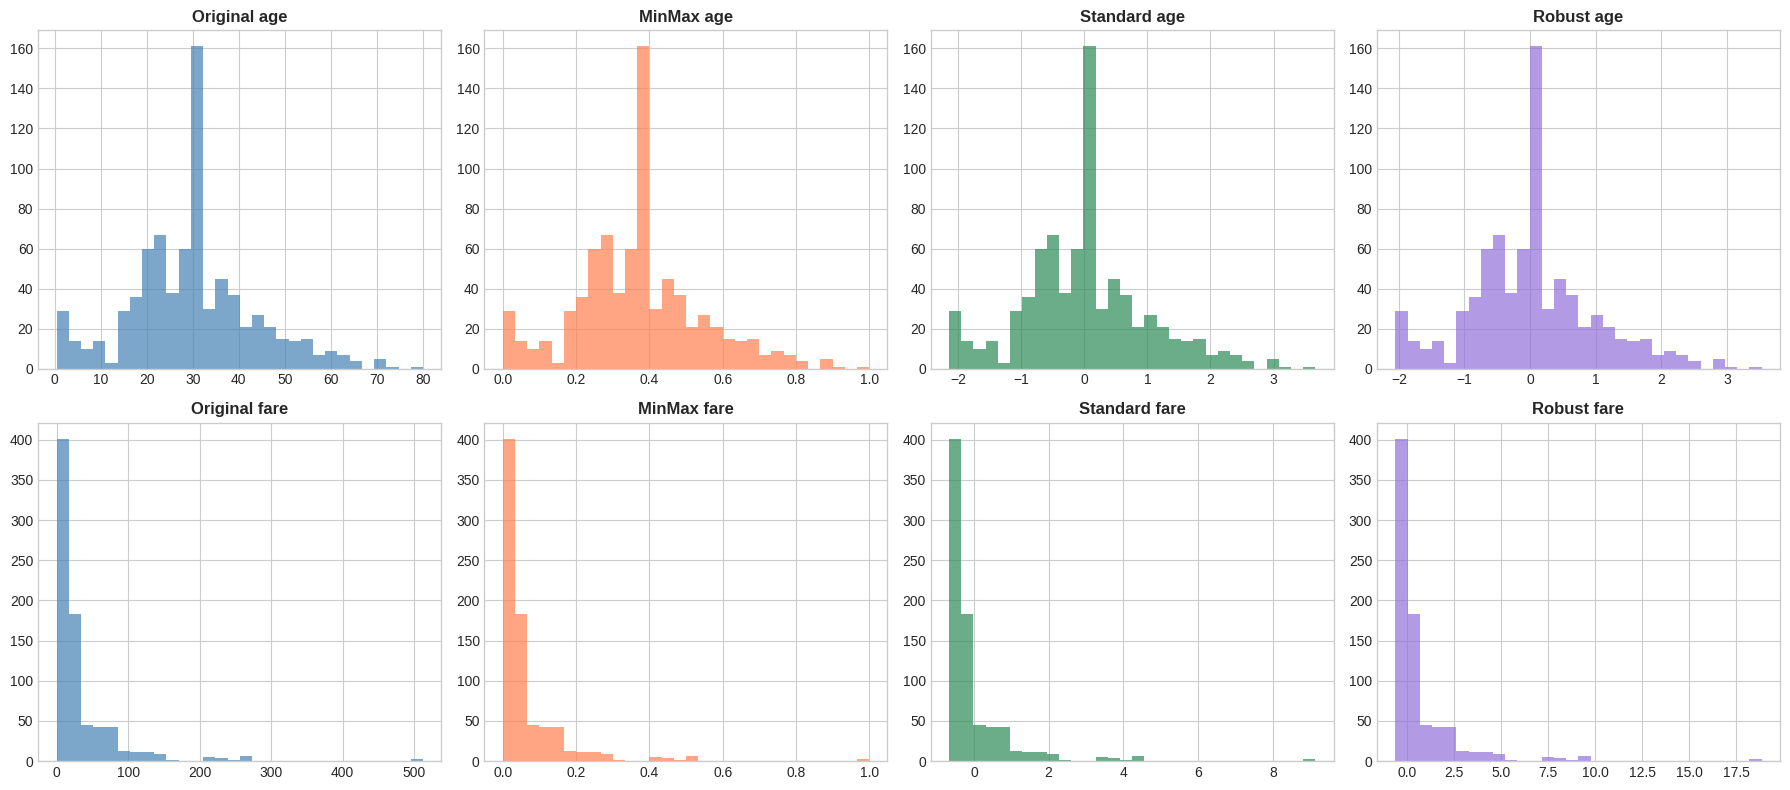

In [144]:
# Visualize scaling effects
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
cols = ['age', 'fare']

for i, col in enumerate(cols):
    axes[i][0].hist(num_data[col], bins=30, color='steelblue', alpha=0.7)
    axes[i][0].set_title(f'Original {col}', fontweight='bold')

    axes[i][1].hist(mm_df[f'{col}_minmax'], bins=30, color='coral', alpha=0.7)
    axes[i][1].set_title(f'MinMax {col}', fontweight='bold')

    axes[i][2].hist(std_df[f'{col}_std'], bins=30, color='seagreen', alpha=0.7)
    axes[i][2].set_title(f'Standard {col}', fontweight='bold')

    axes[i][3].hist(rob_df[f'{col}_robust'], bins=30, color='mediumpurple', alpha=0.7)
    axes[i][3].set_title(f'Robust {col}', fontweight='bold')

plt.tight_layout()
plt.show()

Fare skewness (original): 4.561
Fare skewness (log-transformed): 0.450


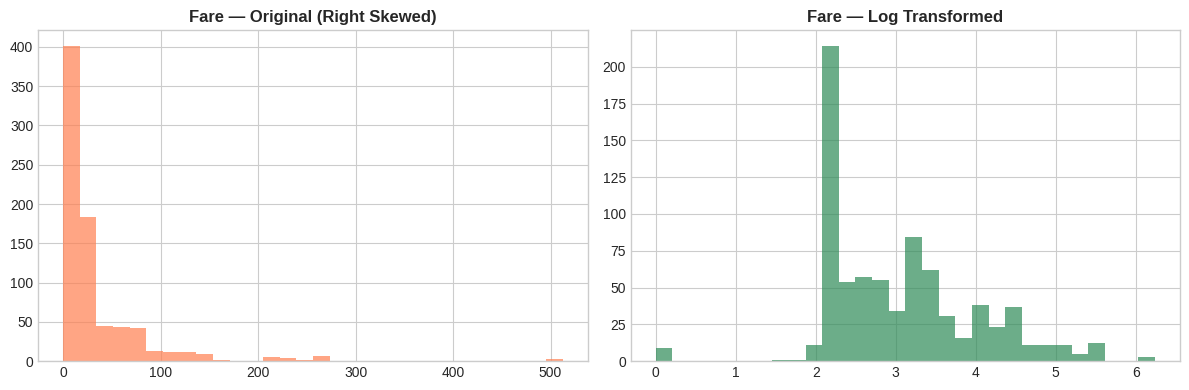

In [145]:
# Log Transformation (handles right skew)
print(f'Fare skewness (original): {df_clean["fare"].skew():.3f}')

fare_log = np.log1p(df_clean['fare'])
print(f'Fare skewness (log-transformed): {fare_log.skew():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean['fare'], bins=30, color='coral', alpha=0.7)
axes[0].set_title('Fare — Original (Right Skewed)', fontweight='bold')

axes[1].hist(fare_log, bins=30, color='seagreen', alpha=0.7)
axes[1].set_title('Fare — Log Transformed', fontweight='bold')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (780). n_quantiles is set to n_samples.
  warnings.warn(


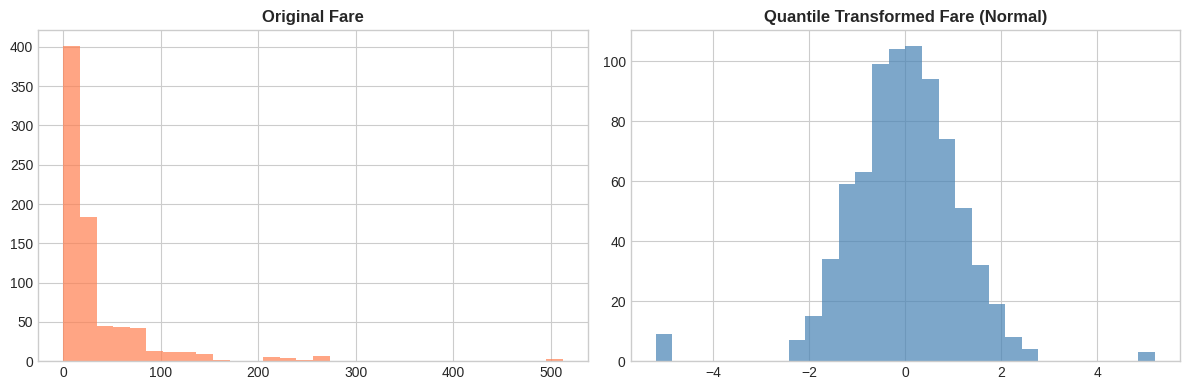

In [146]:
# Quantile Transformation
qt = QuantileTransformer(output_distribution='normal', random_state=42)
fare_qt = qt.fit_transform(df_clean[['fare']])

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_clean['fare'], bins=30, color='coral', alpha=0.7)
plt.title('Original Fare', fontweight='bold')

plt.subplot(1, 2, 2)
plt.hist(fare_qt, bins=30, color='steelblue', alpha=0.7)
plt.title('Quantile Transformed Fare (Normal)', fontweight='bold')

plt.tight_layout()
plt.show()